# NYC Yellow Taxi 2024 — Analyse exploratoire

# 

## Contexte
Le service de taxis jaunes est un acteur historique du transport urbain à New York. Chaque course génère des données détaillées (date, heure, borough de départ et d’arrivée, distance, durée, montant payé, surcharges, etc.).  
Ces données agrégées permettent de comprendre **les tendances de mobilité** et **les dynamiques économiques** de ce secteur emblématique.

## Objectif
L’objectif de cette analyse exploratoire est de :
- Identifier **où** et **quand** les trajets de taxis sont les plus fréquents.  
- Comparer les boroughs de New York en termes de **volume de trajets** et de **revenu moyen par course**.  
- Étudier les **variations temporelles** (par jour et par heure).  
- Évaluer l’impact des **surcharges** (extra, congestion) sur les revenus.  

🎯 À travers cette analyse, il s’agit de mettre en évidence les **facteurs clés qui influencent la rentabilité des trajets** et de proposer des pistes pour aller vers une modélisation prédictive ou un déploiement à plus grande échelle (Big Data / Cloud).


## 2. Chargement et aperçu des données

In [122]:
import pandas as pd

df = pd.read_csv("D:\\aggregated_nyc_yellow_taxi_2024.csv")
print(df.shape)   # combien de lignes, colonnes
print(df.columns) # noms des colonnes
df.head()         # les 5 premières lignes

(921373, 18)
Index(['date', 'hour', 'passenger_count', 'PU_Borough', 'DO_Borough',
       'payment_type', 'trip_count', 'trip_distance_sum', 'duration_sum',
       'fare_amount_sum', 'extra_sum', 'mta_tax_sum', 'tip_amount_sum',
       'tolls_amount_sum', 'improvement_surcharge_sum',
       'congestion_surcharge_sum', 'airport_fee_sum', 'total_amount_sum'],
      dtype='object')


,date,hour,passenger_count,PU_Borough,DO_Borough,payment_type,trip_count,trip_distance_sum,duration_sum,fare_amount_sum,extra_sum,mta_tax_sum,tip_amount_sum,tolls_amount_sum,improvement_surcharge_sum,congestion_surcharge_sum,airport_fee_sum,total_amount_sum
0,2024-01-01,00:00,1.0,Bronx,Bronx,2,2,1.60,9.216667,13.0,2.0,1.0,0.00,0.00,2.0,0.0,0.00,18.00
1,2024-01-01,00:00,1.0,Bronx,Manhattan,2,1,7.50,18.666667,32.4,1.0,0.5,0.00,0.00,1.0,0.0,0.00,34.90
2,2024-01-01,00:00,1.0,Brooklyn,Brooklyn,1,6,10.28,42.750000,60.7,6.0,3.0,11.65,0.00,6.0,0.0,0.00,87.35
3,2024-01-01,00:00,1.0,Brooklyn,Brooklyn,2,4,5.89,38.050000,70.6,3.0,1.5,0.00,0.00,4.0,0.0,1.75,80.85
4,2024-01-01,00:00,1.0,Brooklyn,Manhattan,1,10,53.13,263.683333,303.0,12.5,5.0,67.20,13.88,10.0,25.0,0.00,436.58


In [17]:
df.info()           # types de colonnes
df.describe()       # stats de base
df['PU_Borough'].value_counts()  # fréquence des zones départ

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921373 entries, 0 to 921372
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   date                       921373 non-null  object 
 1   hour                       921373 non-null  object 
 2   passenger_count            921373 non-null  object 
 3   PU_Borough                 921373 non-null  object 
 4   DO_Borough                 921373 non-null  object 
 5   payment_type               921373 non-null  int64  
 6   trip_count                 921373 non-null  int64  
 7   trip_distance_sum          921373 non-null  float64
 8   duration_sum               921373 non-null  float64
 9   fare_amount_sum            921373 non-null  float64
 10  extra_sum                  921373 non-null  float64
 11  mta_tax_sum                921373 non-null  float64
 12  tip_amount_sum             921373 non-null  float64
 13  tolls_amount_sum           92

PU_Borough
Manhattan        403457
Queens           328398
Brooklyn          91214
Unknown           57193
Bronx             39140
EWR                 987
Staten Island       984
Name: count, dtype: int64

In [23]:
df = df[(df['trip_distance_sum'] > 0) & (df['fare_amount_sum'] > 0)]

In [21]:
df.groupby("PU_Borough")["trip_count"].sum().sort_values(ascending=False)

PU_Borough
Manhattan        35000569
Queens            3599033
Brooklyn           544612
Unknown            120509
Bronx              112899
EWR                  1046
Staten Island        1040
Name: trip_count, dtype: int64

In [25]:
df.groupby("PU_Borough")["total_amount_sum"].sum().sort_values(ascending=False)


PU_Borough
Manhattan        8.354027e+08
Queens           2.611559e+08
Brooklyn         1.707343e+07
Unknown          4.081407e+06
Bronx            4.013985e+06
EWR              9.972225e+04
Staten Island    5.296805e+04
Name: total_amount_sum, dtype: float64

# 3. Analyse spatiale (PU/DO Boroughs)

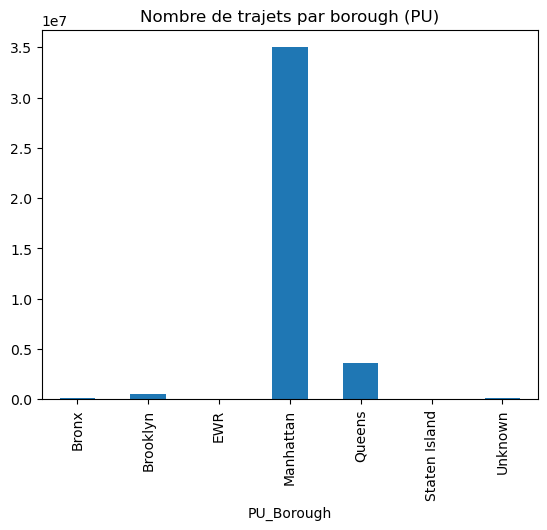

In [131]:
import matplotlib.pyplot as plt
#Création du graphique
df.groupby("PU_Borough")["trip_count"].sum().plot(kind="bar")
plt.title("Nombre de trajets par borough (PU)")
# Sauvegarde
plt.savefig("figures/trajets_par_jour.png", bbox_inches="tight", dpi=150)

plt.show()


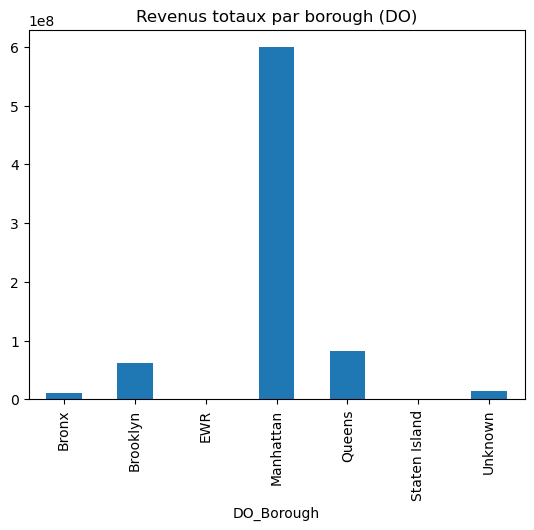

In [133]:
df.groupby("DO_Borough")["fare_amount_sum"].sum().plot(kind="bar")
plt.title("Revenus totaux par borough (DO)")
plt.savefig("figures/Revenus_totaux_par_boough.png", bbox_inches="tight", dpi=150)
plt.show()

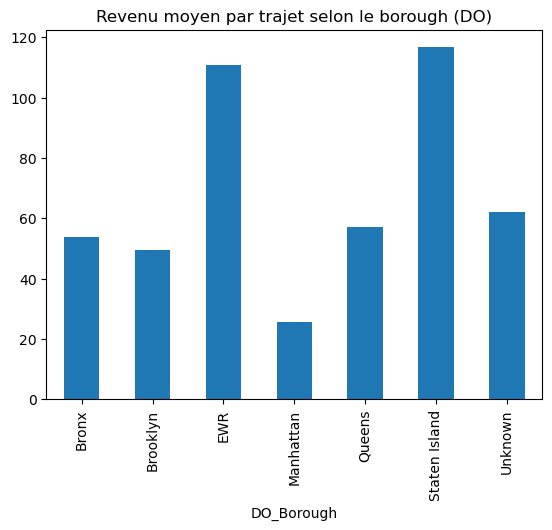

In [135]:
revenus = df.groupby("DO_Borough")["total_amount_sum"].sum()
trajets = df.groupby("DO_Borough")["trip_count"].sum()

revenu_moyen = revenus / trajets
revenu_moyen.plot(kind="bar")
plt.title("Revenu moyen par trajet selon le borough (DO)")
plt.savefig("figures/Revenu_moyen_par_trajet_selon_selon_le_borough.png", bbox_inches="tight", dpi=150)
plt.show()

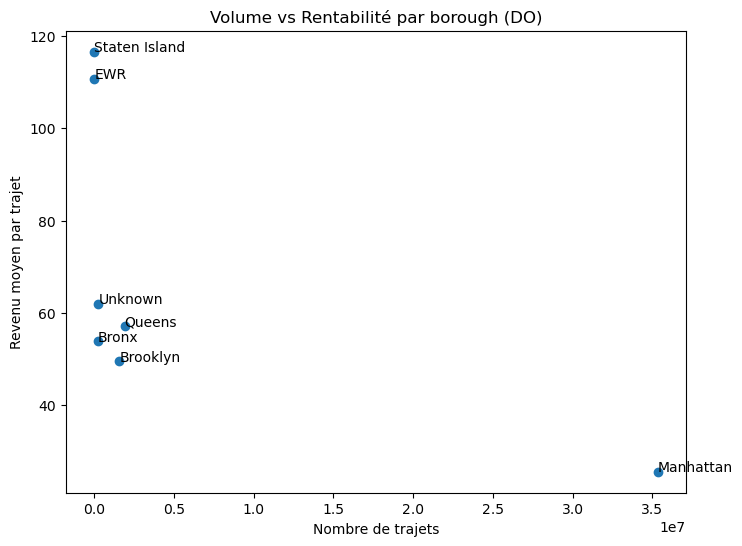

In [141]:
import matplotlib.pyplot as plt

trajets = df.groupby("DO_Borough")["trip_count"].sum()
revenu_moyen = df.groupby("DO_Borough")["total_amount_sum"].sum() / trajets

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(trajets, revenu_moyen)

for b in trajets.index:
    plt.text(trajets[b], revenu_moyen[b], b)

plt.xlabel("Nombre de trajets")
plt.ylabel("Revenu moyen par trajet")
plt.title("Volume vs Rentabilité par borough (DO)")
plt.savefig("figures/Volume_vs_Rentabilité_par_borough_DO.png", bbox_inches="tight", dpi=150)
plt.show()

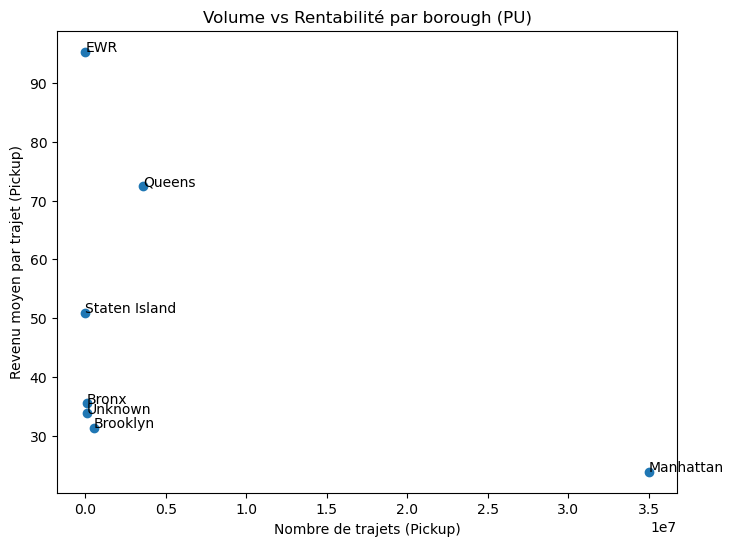

In [143]:
trajets_PU = df.groupby("PU_Borough")["trip_count"].sum()
revenu_moyen_PU = df.groupby("PU_Borough")["total_amount_sum"].sum() / trajets_PU

plt.figure(figsize=(8,6))
plt.scatter(trajets_PU, revenu_moyen_PU)

for b in trajets_PU.index:
    plt.text(trajets_PU[b], revenu_moyen_PU[b], b)

plt.xlabel("Nombre de trajets (Pickup)")
plt.ylabel("Revenu moyen par trajet (Pickup)")
plt.title("Volume vs Rentabilité par borough (PU)")
plt.savefig("figures/Volume_vs_Rentabilité_par_borough_PU.png", bbox_inches="tight", dpi=150)
plt.show()


# 📊 Insight Spatial

## **Observations**
- Les pickups et dropoffs sont fortement concentrés à **Manhattan** (part majoritaire des trajets).  
- Le **revenu moyen par trajet** est plus faible à Manhattan (trajets courts), et plus élevé à **Queens** ;  
  **Staten Island / EWR** affichent des revenus unitaires très hauts mais un volume très faible.  
- Les flux inter-borough dominants semblent être **Manhattan ↔ Queens** (à confirmer via l’analyse des top couples PU→DO).  
- À granularité “zone”, certaines zones de **Midtown/Lower Manhattan** concentrent l’essentiel des pickups (hotspots intra-borough).  

## **Interprétations possibles (à confirmer)**
- Le revenu plus élevé à Queens pourrait refléter une proportion plus forte de trajets longue distance (ex. aéroports), mais les **surcharges** jouent aussi un rôle (effet heure/jour).  
- Les couples **Manhattan → Queens** et **Queens → Manhattan** peuvent être asymétriques (trafic entrant vs sortant différent selon les heures/jours).  

## **Que retenir pour la suite ?**
- Le marché taxi est **bi-modale** : volume court intra-Manhattan vs trajets longue distance à forte valeur (Queens/EWR).  
- Pour éviter le biais lié à la distance, il est utile de comparer le **revenu par mile** en plus du revenu moyen par trajet.  


# 4. Analyse temporelle (jours de la semaine)


In [157]:
import pandas as pd

# Convertir colonne 'date' en format datetime
df["date"] = pd.to_datetime(df["date"])

# Créer nouvelle colonne 'day' avec le jour de la semaine
df["day"] = df["date"].dt.day_name()

# Vérifions
print(df[["date", "day"]].head())


        date     day
0 2024-01-01  Monday
1 2024-01-01  Monday
2 2024-01-01  Monday
3 2024-01-01  Monday
4 2024-01-01  Monday


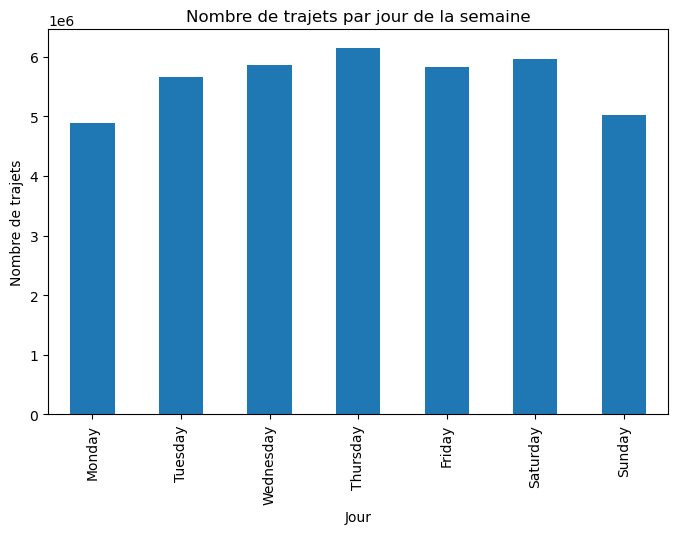

In [159]:
# Redéfinir l’ordre des jours
jours_ordre = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df.groupby("day")["trip_count"].sum().reindex(jours_ordre).plot(kind="bar", figsize=(8,5))
plt.title("Nombre de trajets par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Nombre de trajets")
plt.savefig("figures/trajets_par_jour_de_la_semaine.png", bbox_inches="tight", dpi=150)
plt.show()


In [161]:
# Redéfinir l’ordre des jours
jours_ordre = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Regrouper les trajets par jour
trajets_par_jour = df.groupby("day")["trip_count"].sum().reindex(jours_ordre)

# Semaine vs week-end
semaine = trajets_par_jour[:5].sum()
weekend = trajets_par_jour[5:].sum()

print("Trajets semaine :", semaine)
print("Trajets week-end :", weekend)


Trajets semaine : 28390115
Trajets week-end : 10989593


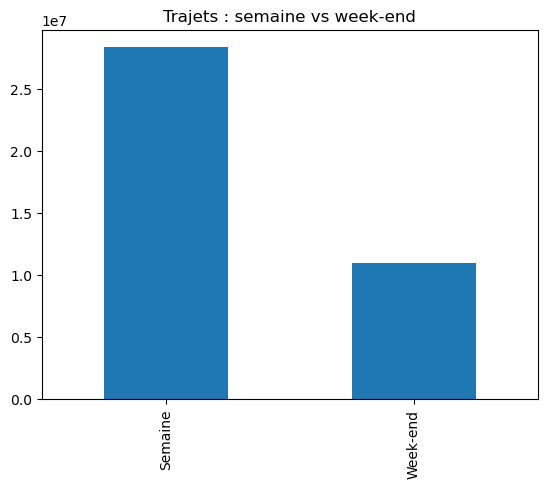

In [163]:
pd.Series({"Semaine": semaine, "Week-end": weekend}).plot(kind="bar")
plt.title("Trajets : semaine vs week-end")
plt.savefig("figures/Trajets_semaine_vs_week-end.png", bbox_inches="tight", dpi=150)
plt.show()


# 📊 Insight Temporel – Jours de la semaine

## **Observations**
- Le nombre de trajets est **plus élevé du mardi au samedi**.  
- **Lundi et dimanche** sont les jours les moins chargés.  

## **Interprétations possibles**
- Cela pourrait refléter une **activité professionnelle plus forte en semaine**, avec un pic supplémentaire le samedi dû aux **sorties et déplacements de loisirs**.  
- Le calme du dimanche peut indiquer une **demande plus faible globale**, mais cette hypothèse ne peut pas être confirmée uniquement avec ces données.  

## **Que retenir pour la suite ?**
- L’activité des taxis suit un **cycle hebdomadaire marqué** : fort en semaine et le samedi, plus faible le dimanche.  
- Pour compléter l’analyse, il serait pertinent de distinguer **semaine vs week-end** et d’examiner si les **revenus moyens par trajet** suivent la même dynamique que le volume.  


# 5. Analyse temporelle (heures de la journée)

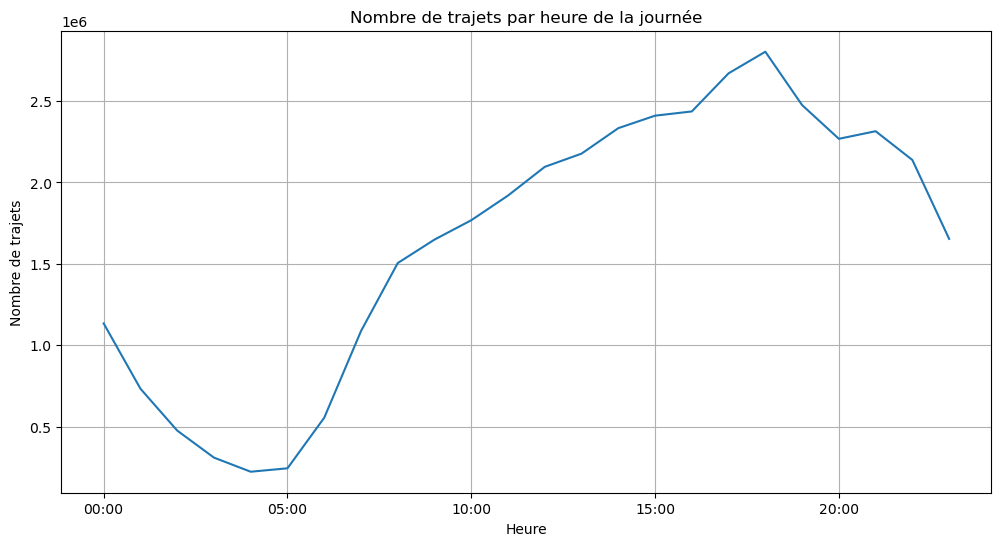

In [165]:
df.groupby("hour")["trip_count"].sum().plot(kind="line", figsize=(12,6))
plt.title("Nombre de trajets par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Nombre de trajets")
plt.grid(True)
plt.savefig("figures/trajets_par_heure_de_la_journée.png", bbox_inches="tight", dpi=150)
plt.show()

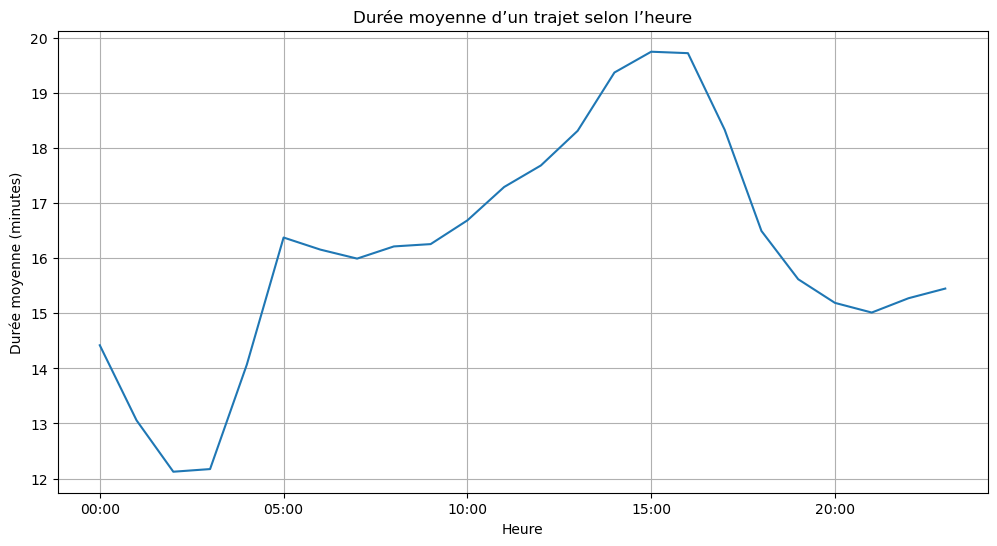

In [167]:
(df.groupby("hour")["duration_sum"].sum() / df.groupby("hour")["trip_count"].sum()).plot(kind="line", figsize=(12,6))
plt.title("Durée moyenne d’un trajet selon l’heure")
plt.xlabel("Heure")
plt.ylabel("Durée moyenne (minutes)")
plt.grid(True)
plt.savefig("figures/Durée_moyenne_d1_trajet_selon_l_heure.png", bbox_inches="tight", dpi=150)
plt.show()


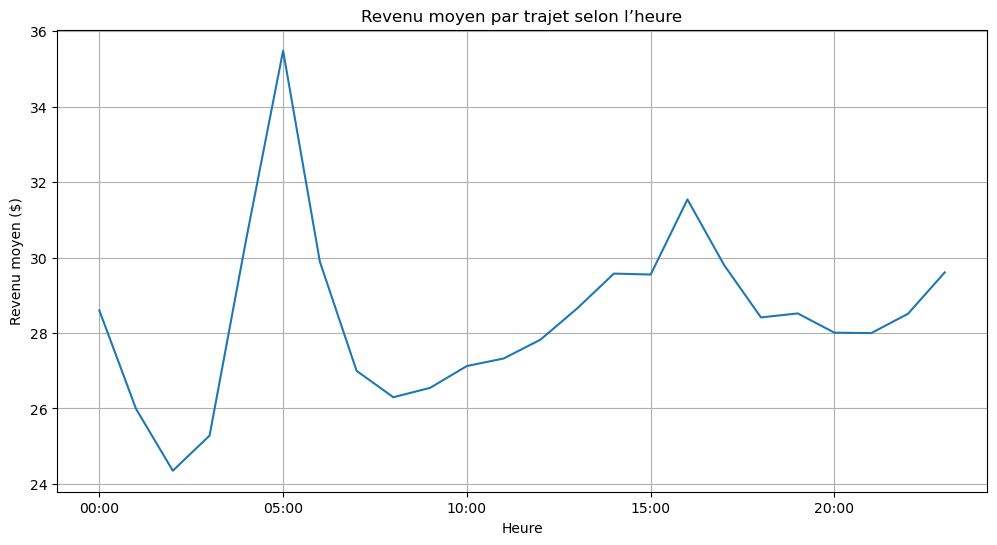

In [171]:
(df.groupby("hour")["total_amount_sum"].sum() / df.groupby("hour")["trip_count"].sum()).plot(kind="line", figsize=(12,6))
plt.title("Revenu moyen par trajet selon l’heure")
plt.xlabel("Heure")
plt.ylabel("Revenu moyen ($)")
plt.grid(True)
plt.savefig("figures/Revenu_moyen_par_trajet_selon_l_heure.png", bbox_inches="tight", dpi=150)
plt.show()


# 📊 Insight Temporel – Heures de la journée

## **Observations**
- Deux pics apparaissent : un **tôt le matin (~5h)** et un autre **en fin d’après-midi (16–18h)**.  
- Le **revenu moyen par trajet** est plus élevé aux **heures creuses de la nuit** et **tôt le matin**.  

## **Interprétations possibles**
- Les trajets du matin peuvent inclure des **courses vers les aéroports**, ce qui augmenterait la distance et donc le revenu moyen.  
- Les trajets de fin d’après-midi traduisent probablement une **hausse générale de la demande**, mais plusieurs facteurs (congestion, surcharges, flux domicile-travail) peuvent aussi jouer.  

## **Que retenir pour la suite ?**
- L’activité des taxis suit un **rythme journalier marqué** avec deux pics distincts.  
- Le revenu moyen est influencé non seulement par la **demande** mais aussi par la **nature des trajets** et les **mécanismes tarifaires** (surcharges).  
- Une extension pertinente serait d’analyser la **durée et la distance moyenne des trajets par heure** pour confirmer ces hypothèses.  


## 6. Facteurs économiques (revenus moyens, surcharges)

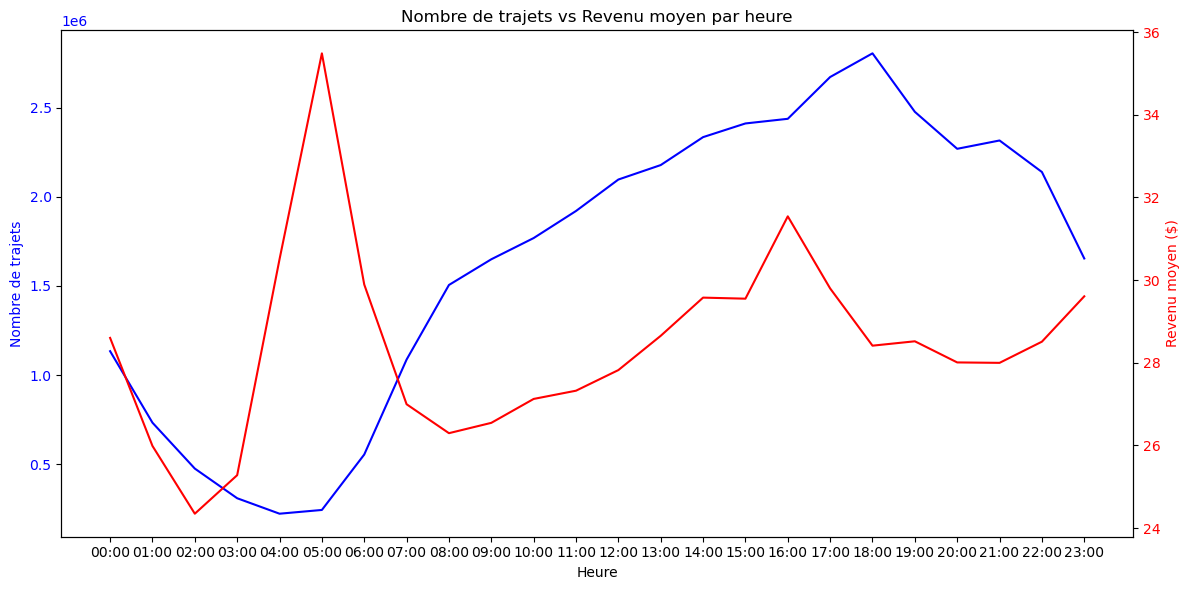

In [173]:
import matplotlib.pyplot as plt

# Volume de trajets par heure
trajets_par_heure = df.groupby("hour")["trip_count"].sum()

# Revenu moyen par heure
revenu_moyen_par_heure = df.groupby("hour")["total_amount_sum"].sum() / trajets_par_heure

# Graphique combiné
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Heure")
ax1.set_ylabel("Nombre de trajets", color="blue")
ax1.plot(trajets_par_heure.index, trajets_par_heure.values, color="blue", label="Nombre de trajets")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()  
ax2.set_ylabel("Revenu moyen ($)", color="red")
ax2.plot(revenu_moyen_par_heure.index, revenu_moyen_par_heure.values, color="red", label="Revenu moyen")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Nombre de trajets vs Revenu moyen par heure")
fig.tight_layout()
plt.savefig("figures/Nombre_de_trajets_vs_Revenu_moyen_par_heure.png", bbox_inches="tight", dpi=150)
plt.show()


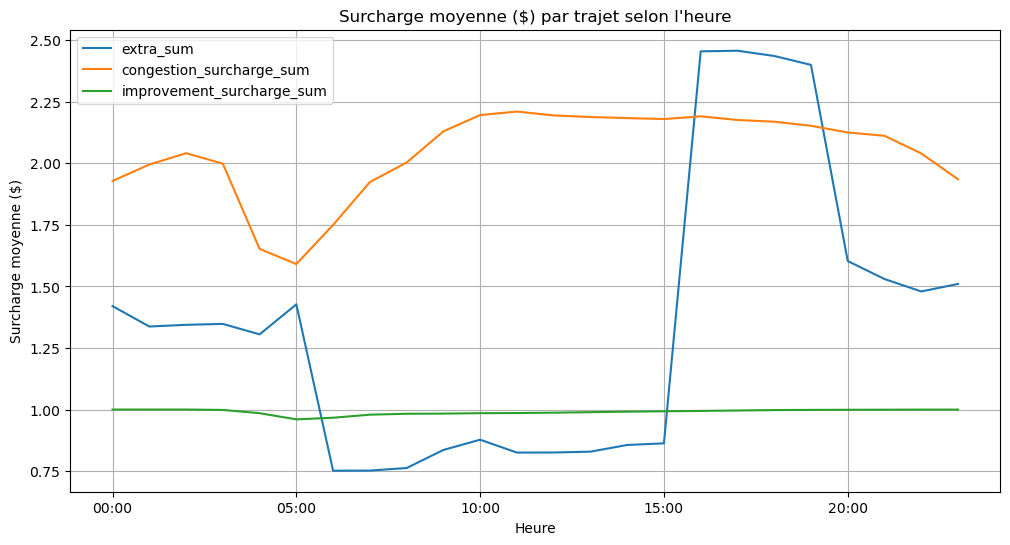

In [175]:
# Moyenne des surcharges par trajet selon l'heure
surcharge_moyenne = (
    df.groupby("hour")[["extra_sum", "congestion_surcharge_sum", "improvement_surcharge_sum"]].sum()
    / df.groupby("hour")["trip_count"].sum().values.reshape(-1,1)
)

surcharge_moyenne.plot(kind="line", figsize=(12,6))
plt.title("Surcharge moyenne ($) par trajet selon l'heure")
plt.xlabel("Heure")
plt.ylabel("Surcharge moyenne ($)")
plt.grid(True)
plt.savefig("figures/Surcharge_moyenne_par_trajet_selon_l_heure.png", bbox_inches="tight", dpi=150)
plt.show()


# 📊 Insight – Impact des surcharges

## **Observations**
- Les **surcharges “extra”** augmentent le prix moyen des courses la nuit et aux heures de pointe.  
- Les **surcharges de congestion** apparaissent surtout en journée et accentuent l’écart entre les heures creuses et les heures chargées.  

## **Interprétations possibles**
- Ces mécanismes tarifaires contribuent directement à la **variation du revenu moyen par trajet** au fil de la journée.  
- Ils montrent que la **réglementation et le contexte urbain** (circulation dense, horaires spécifiques) influencent autant la rentabilité que la distance parcourue.  

## **Que retenir pour la suite ?**
- Les revenus des taxis sont **fortement dépendants des politiques tarifaires** et pas seulement des distances.  
- Les surcharges jouent un rôle clé dans la **différenciation des revenus par heure**, ce qui en fait une variable cruciale à intégrer dans tout modèle prédictif futur.  
- Une extension pertinente serait d’évaluer le **poids relatif des surcharges vs distance/durée** dans le revenu global.  


# 🏁 Conclusion

## **Observations générales**
- **Manhattan** concentre la majorité des trajets, mais avec un **revenu moyen plus faible** (~25 $/course).  
- **Queens** affiche un **revenu moyen plus élevé** (~58 $), notamment grâce aux trajets vers les aéroports (JFK, LaGuardia).  
- Les trajets sont **plus nombreux du mardi au samedi**, avec des pics marqués aux heures de pointe (matin et fin de journée).  
- Les **surcharges** (extra la nuit, congestion en journée) contribuent directement à la variation du revenu moyen par heure.  

## **Que retenir ?**
Ces résultats mettent en évidence un équilibre entre :  
- un **marché de masse** (trajets courts intra-Manhattan, volume élevé, revenu unitaire faible),  
- et un **marché de niche rentable** (trajets longue distance/aéroports, volume plus faible, revenu unitaire élevé).  

## 🚀 **Perspectives**
- Approfondir avec une **analyse prédictive** de la demande (forecast de trajets par heure/jour).  
- Étudier l’évolution **sur plusieurs années** pour mettre en lumière les tendances structurelles.  
- Déployer un **pipeline Big Data** sur le cloud (AWS/Azure/GCP) afin de passer à l’échelle et d’intégrer de nouvelles sources de données (trafic, météo, événements).  
